# 03a — Spatial Features: OSM Vector Data
## MietOptimal / RentSignal

Extract neighborhood-level spatial features from OpenStreetMap for each Berlin PLZ:
- **Transit proximity**: distance to nearest U-Bahn/S-Bahn station
- **POI density**: restaurants/cafes, shops/supermarkets within 500m radius
- **Green access**: distance to nearest park
- **Water proximity**: distance to nearest river/canal/lake
- **School proximity**: distance to nearest school/kindergarten

Output: `data/processed/spatial_osm_features.csv` — one row per PLZ with all spatial features.

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import json
import time
from shapely.geometry import Point, MultiPolygon
from shapely.ops import nearest_points
import warnings
warnings.filterwarnings("ignore")

print("All imports loaded successfully")

All imports loaded successfully


## 1. Load listings and get unique PLZs

In [3]:
# Load clean listings
listings = pd.read_parquet("../data/processed/listings_clean.parquet")
plz_list = listings["plz"].dropna().unique()
# PLZ is stored as string — filter to valid Berlin PLZs (5-digit, starting with 1)
plz_list = np.array([p for p in plz_list if str(p).startswith("1") and len(str(p)) == 5])
print(f"Unique Berlin PLZs: {len(plz_list)}")
print(f"Sample: {sorted(plz_list)[:5]} ... {sorted(plz_list)[-5:]}")

Unique Berlin PLZs: 214
Sample: [np.str_('10017'), np.str_('10115'), np.str_('10117'), np.str_('10119'), np.str_('10171')] ... [np.str_('14193'), np.str_('14195'), np.str_('14197'), np.str_('14199'), np.str_('19437')]


## 2. Get Berlin PLZ boundaries + centroids

Download PLZ boundary polygons and compute centroids for distance calculations.

In [5]:
# Build PLZ string set first
plz_str_list = set(str(p) for p in plz_list)

# Try multiple PLZ boundary sources (in order of reliability)
PLZ_SOURCES = [
    ("OpenDataSoft", "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/georef-germany-postleitzahl/exports/geojson?where=lan_name%20%3D%20%22Berlin%22&limit=-1"),
    ("suche-postleitzahl.org", "https://downloads.suche-postleitzahl.org/v2/public/plz-5stellig.geojson"),
    ("GitHub launist", "https://raw.githubusercontent.com/launist/german-postal-codes/master/data/plz-5stellig-centroid.geojson"),
]

plz_all = None
for name, url in PLZ_SOURCES:
    try:
        print(f"Trying {name}...", end=" ")
        plz_all = gpd.read_file(url)
        print(f"✓ {len(plz_all)} polygons")
        break
    except Exception as e:
        print(f"✗ ({type(e).__name__})")

if plz_all is None:
    # Fallback: geocode each PLZ via Nominatim (free, no API key)
    print("\nAll file sources failed. Using Nominatim geocoding for 214 PLZs (~2 min)...")
    
    centroids = []
    BASE = "https://nominatim.openstreetmap.org/search"
    for i, plz in enumerate(sorted(plz_str_list)):
        if i % 50 == 0 and i > 0:
            print(f"  Geocoded {i}/{len(plz_str_list)}...")
        try:
            resp = requests.get(BASE, params={"postalcode": plz, "country": "Germany", "format": "json", "limit": 1},
                              headers={"User-Agent": "MietOptimal-Research/1.0"}, timeout=10)
            data = resp.json()
            if data:
                centroids.append({"plz": plz, "geometry": Point(float(data[0]["lon"]), float(data[0]["lat"]))})
        except:
            pass
        time.sleep(0.5)  # respect Nominatim rate limit (1 req/s)
    
    plz_gdf = gpd.GeoDataFrame(centroids, crs="EPSG:4326").to_crs(epsg=25833)
    plz_gdf["centroid"] = plz_gdf.geometry
    print(f"\nGeocoded {len(plz_gdf)} PLZ centroids via Nominatim")
else:
    # Filter to Berlin PLZs
    plz_col = "plz" if "plz" in plz_all.columns else plz_all.columns[0]
    plz_all["plz"] = plz_all[plz_col].astype(str)
    plz_gdf = plz_all[plz_all["plz"].isin(plz_str_list)].copy()
    print(f"Filtered to {len(plz_gdf)} Berlin PLZs matching our listings")
    
    plz_gdf = plz_gdf.to_crs(epsg=25833)
    plz_gdf["centroid"] = plz_gdf.geometry.centroid

print(f"\n{len(plz_gdf)} PLZs ready, CRS: EPSG:25833 (UTM 33N)")
plz_gdf.head()

Trying OpenDataSoft... ✗ (HTTPError)
Trying suche-postleitzahl.org... ✗ (URLError)
Trying GitHub launist... ✗ (HTTPError)

All file sources failed. Using Nominatim geocoding for 214 PLZs (~2 min)...
  Geocoded 50/214...
  Geocoded 100/214...
  Geocoded 150/214...
  Geocoded 200/214...

Geocoded 190 PLZ centroids via Nominatim

190 PLZs ready, CRS: EPSG:25833 (UTM 33N)


,plz,geometry,centroid
0,10115,POINT (390370.31 5821433.112),POINT (390370.31 5821433.112)
1,10117,POINT (390604.024 5819822.125),POINT (390604.024 5819822.125)
2,10119,POINT (391838.617 5821197.572),POINT (391838.617 5821197.572)
3,10178,POINT (392107.99 5820207.84),POINT (392107.99 5820207.84)
4,10179,POINT (392535.903 5819176.613),POINT (392535.903 5819176.613)


## 3. Query OSM Overpass API

Fetch spatial features for Berlin in batches. All queries use the Overpass API with Berlin bounding box.

In [6]:
OVERPASS_URL = "https://overpass-api.de/api/interpreter"

# Berlin bounding box (lat_min, lon_min, lat_max, lon_max)
BERLIN_BBOX = "52.33,13.08,52.68,13.76"

def query_overpass(query, description=""):
    """Send query to Overpass API with retry logic."""
    print(f"  Querying: {description}...", end=" ")
    for attempt in range(3):
        try:
            resp = requests.post(OVERPASS_URL, data={"data": query}, timeout=120)
            if resp.status_code == 200:
                data = resp.json()
                elements = data.get("elements", [])
                print(f"✓ {len(elements)} elements")
                return elements
            elif resp.status_code == 429:
                wait = 30 * (attempt + 1)
                print(f"rate limited, waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"HTTP {resp.status_code}")
                time.sleep(10)
        except Exception as e:
            print(f"error: {e}")
            time.sleep(10)
    print("FAILED after 3 attempts")
    return []

def elements_to_gdf(elements, crs_target=25833):
    """Convert Overpass elements to GeoDataFrame with projected CRS."""
    points = []
    for el in elements:
        if "lat" in el and "lon" in el:
            points.append({
                "geometry": Point(el["lon"], el["lat"]),
                "osm_id": el.get("id"),
                "tags": el.get("tags", {})
            })
        elif el.get("center"):
            points.append({
                "geometry": Point(el["center"]["lon"], el["center"]["lat"]),
                "osm_id": el.get("id"),
                "tags": el.get("tags", {})
            })
    if not points:
        return gpd.GeoDataFrame(columns=["geometry", "osm_id", "tags"], crs="EPSG:4326")
    gdf = gpd.GeoDataFrame(points, crs="EPSG:4326")
    return gdf.to_crs(epsg=crs_target)

print("Helper functions defined")

Helper functions defined


In [7]:
# --- 3a. U-Bahn / S-Bahn stations ---
transit_query = f"""
[out:json][timeout:60];
(
  node["railway"="station"]["station"~"subway|light_rail"]({BERLIN_BBOX});
  node["railway"="stop"]["station"~"subway|light_rail"]({BERLIN_BBOX});
  node["railway"="station"]["network"~"S-Bahn|U-Bahn|VBB"]({BERLIN_BBOX});
);
out center;
"""
transit_elements = query_overpass(transit_query, "U-Bahn/S-Bahn stations")
transit_gdf = elements_to_gdf(transit_elements)
transit_gdf["name"] = transit_gdf["tags"].apply(lambda t: t.get("name", ""))
print(f"  Sample stations: {transit_gdf['name'].head(5).tolist()}")

time.sleep(5)  # be nice to Overpass

# --- 3b. Restaurants & Cafes ---
food_query = f"""
[out:json][timeout:60];
(
  node["amenity"="restaurant"]({BERLIN_BBOX});
  node["amenity"="cafe"]({BERLIN_BBOX});
);
out;
"""
food_elements = query_overpass(food_query, "Restaurants & cafes")
food_gdf = elements_to_gdf(food_elements)

time.sleep(5)

# --- 3c. Shops & Supermarkets ---
shop_query = f"""
[out:json][timeout:60];
(
  node["shop"="supermarket"]({BERLIN_BBOX});
  node["shop"="convenience"]({BERLIN_BBOX});
);
out;
"""
shop_elements = query_overpass(shop_query, "Shops & supermarkets")
shop_gdf = elements_to_gdf(shop_elements)

time.sleep(5)

# --- 3d. Parks (as polygons — get centers) ---
park_query = f"""
[out:json][timeout:60];
(
  way["leisure"="park"]({BERLIN_BBOX});
  relation["leisure"="park"]({BERLIN_BBOX});
);
out center;
"""
park_elements = query_overpass(park_query, "Parks")
park_gdf = elements_to_gdf(park_elements)

time.sleep(5)

# --- 3e. Water bodies ---
water_query = f"""
[out:json][timeout:60];
(
  way["natural"="water"]({BERLIN_BBOX});
  way["waterway"="river"]({BERLIN_BBOX});
  way["waterway"="canal"]({BERLIN_BBOX});
  relation["natural"="water"]({BERLIN_BBOX});
);
out center;
"""
water_elements = query_overpass(water_query, "Water bodies")
water_gdf = elements_to_gdf(water_elements)

time.sleep(5)

# --- 3f. Schools & Kindergartens ---
school_query = f"""
[out:json][timeout:60];
(
  node["amenity"="school"]({BERLIN_BBOX});
  way["amenity"="school"]({BERLIN_BBOX});
  node["amenity"="kindergarten"]({BERLIN_BBOX});
  way["amenity"="kindergarten"]({BERLIN_BBOX});
);
out center;
"""
school_elements = query_overpass(school_query, "Schools & kindergartens")
school_gdf = elements_to_gdf(school_elements)

print(f"\n--- Summary ---")
print(f"Transit stations:     {len(transit_gdf)}")
print(f"Restaurants/cafes:    {len(food_gdf)}")
print(f"Shops/supermarkets:   {len(shop_gdf)}")
print(f"Parks:                {len(park_gdf)}")
print(f"Water bodies:         {len(water_gdf)}")
print(f"Schools/kindergartens:{len(school_gdf)}")

  Querying: U-Bahn/S-Bahn stations... ✓ 275 elements
  Sample stations: ['Tiergarten', 'Westend', 'Wannsee', 'Pichelsberg', 'Grunewald']
  Querying: Restaurants & cafes... ✓ 7396 elements
  Querying: Shops & supermarkets... rate limited, waiting 30s...
rate limited, waiting 60s...
✓ 2048 elements
  Querying: Parks... ✓ 3004 elements
  Querying: Water bodies... rate limited, waiting 30s...
✓ 2922 elements
  Querying: Schools & kindergartens... ✓ 3823 elements

--- Summary ---
Transit stations:     275
Restaurants/cafes:    7396
Shops/supermarkets:   2048
Parks:                3004
Water bodies:         2922
Schools/kindergartens:3823


## 4. Compute spatial features per PLZ

For each PLZ centroid, compute:
- **Distance features** (meters): nearest transit station, park, water body, school
- **Density features** (counts): restaurants/cafes and shops within 500m radius

In [8]:
from shapely import unary_union

def nearest_distance(centroid, target_gdf):
    """Distance (meters) from centroid to nearest feature in target_gdf."""
    if target_gdf.empty:
        return np.nan
    all_points = unary_union(target_gdf.geometry)
    nearest = nearest_points(centroid, all_points)[1]
    return centroid.distance(nearest)

def count_within_radius(centroid, target_gdf, radius_m=500):
    """Count features within radius (meters) of centroid."""
    if target_gdf.empty:
        return 0
    buffer = centroid.buffer(radius_m)
    return target_gdf.geometry.within(buffer).sum()

# Compute features for each PLZ
results = []

for idx, row in plz_gdf.iterrows():
    c = row["centroid"]
    plz = row["plz"]
    
    feat = {
        "plz": plz,
        # Distance to nearest (meters)
        "dist_transit_m": nearest_distance(c, transit_gdf),
        "dist_park_m": nearest_distance(c, park_gdf),
        "dist_water_m": nearest_distance(c, water_gdf),
        "dist_school_m": nearest_distance(c, school_gdf),
        # Density within 500m
        "count_food_500m": count_within_radius(c, food_gdf, 500),
        "count_shop_500m": count_within_radius(c, shop_gdf, 500),
        # Density within 1000m (broader walkability)
        "count_food_1000m": count_within_radius(c, food_gdf, 1000),
        "count_shop_1000m": count_within_radius(c, shop_gdf, 1000),
        "count_transit_1000m": count_within_radius(c, transit_gdf, 1000),
    }
    results.append(feat)

spatial_df = pd.DataFrame(results)
print(f"Computed spatial features for {len(spatial_df)} PLZs")
spatial_df.describe().round(0)

Computed spatial features for 190 PLZs


,dist_transit_m,dist_park_m,dist_water_m,dist_school_m,count_food_500m,count_shop_500m,count_food_1000m,count_shop_1000m,count_transit_1000m
count,190.0,190.0,190.0,190.0,190.0,190.0,190.0,190.0,190.0
mean,983.0,330.0,492.0,259.0,20.0,5.0,72.0,18.0,2.0
std,891.0,300.0,271.0,258.0,30.0,7.0,99.0,22.0,2.0
min,53.0,16.0,9.0,1.0,0.0,0.0,0.0,0.0,0.0
25%,371.0,160.0,297.0,114.0,1.0,0.0,7.0,3.0,0.0
50%,695.0,232.0,462.0,192.0,5.0,2.0,20.0,8.0,1.0
75%,1302.0,409.0,647.0,312.0,26.0,7.0,110.0,28.0,3.0
max,5531.0,1783.0,1490.0,2309.0,139.0,32.0,421.0,99.0,12.0


## 5. Visualize spatial features

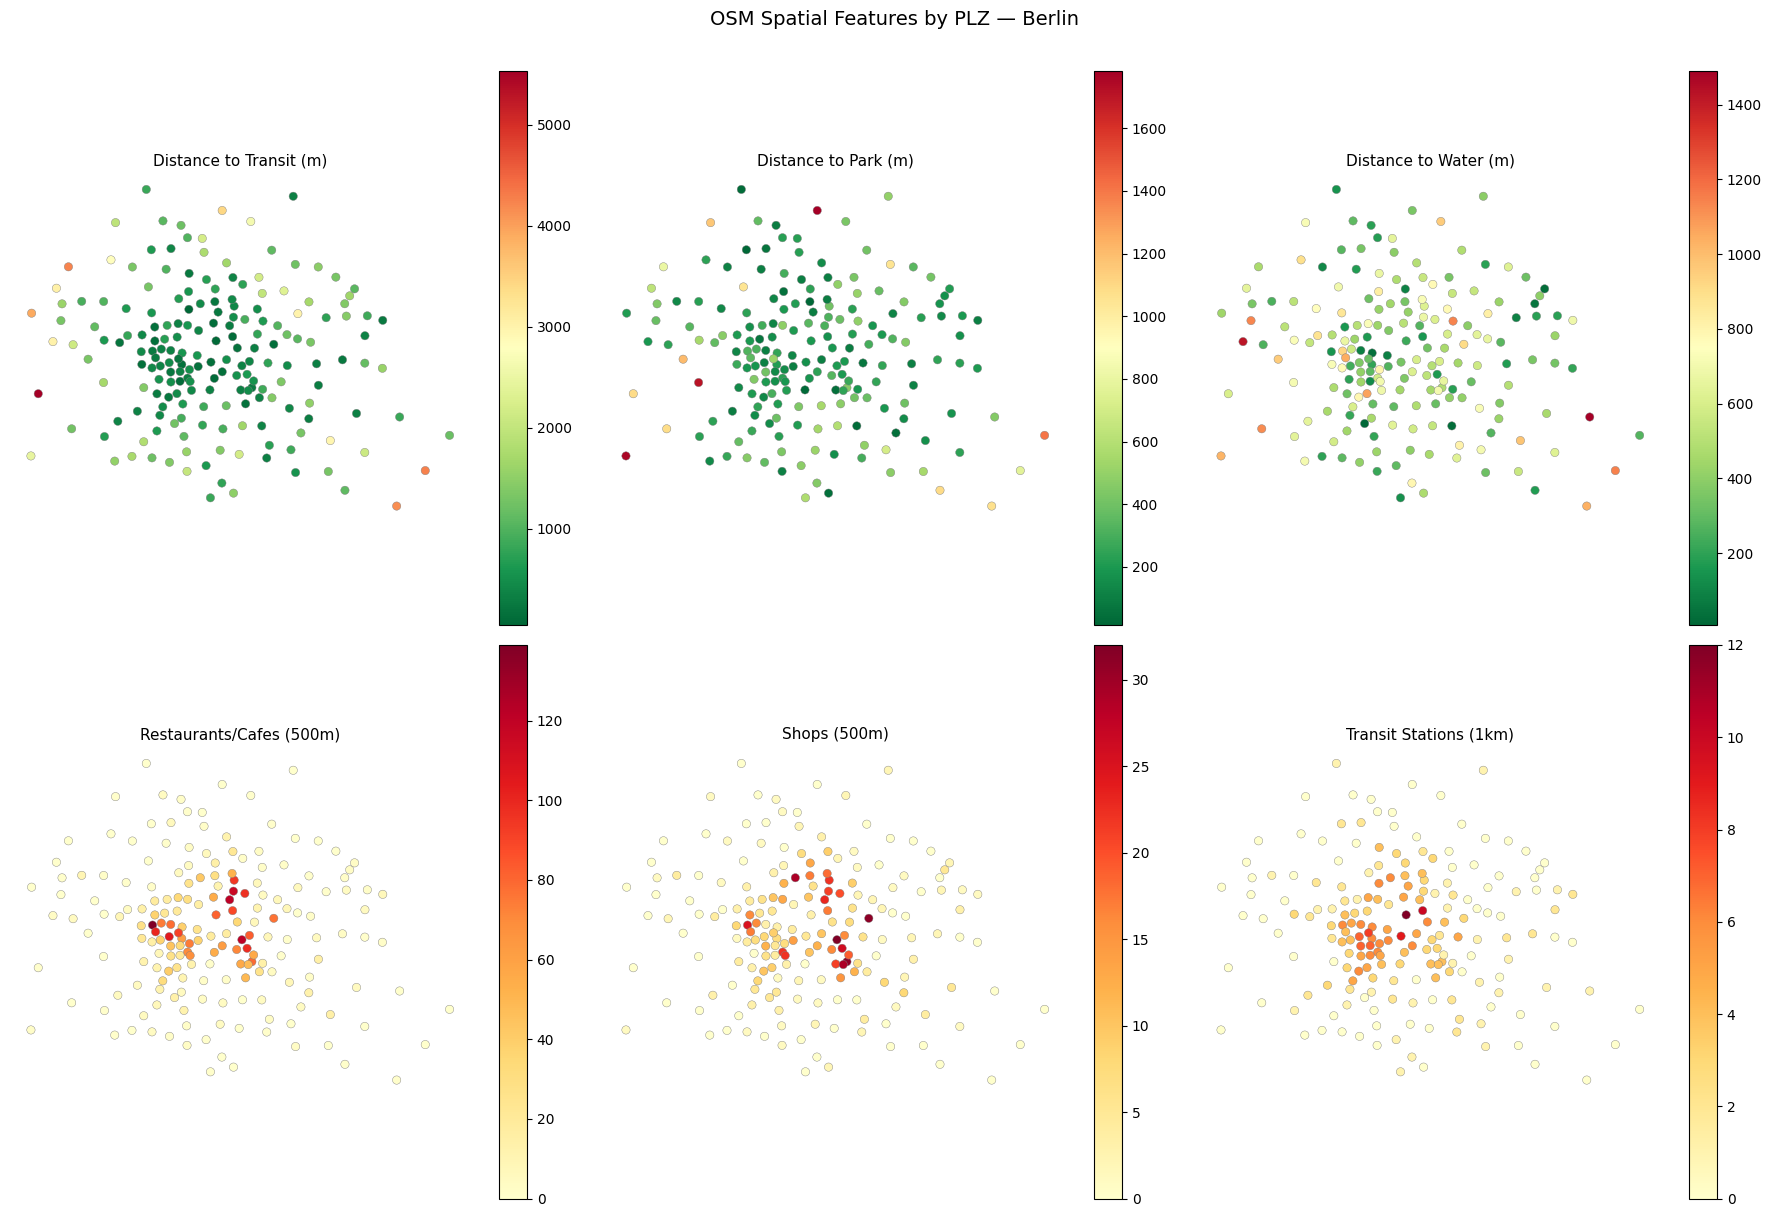

Maps saved to data/processed/spatial_osm_maps.png


In [9]:
import matplotlib.pyplot as plt

# Merge spatial features back to PLZ polygons for mapping
plz_viz = plz_gdf.merge(spatial_df, on="plz", how="left")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

features_to_plot = [
    ("dist_transit_m", "Distance to Transit (m)", "RdYlGn_r"),
    ("dist_park_m", "Distance to Park (m)", "RdYlGn_r"),
    ("dist_water_m", "Distance to Water (m)", "RdYlGn_r"),
    ("count_food_500m", "Restaurants/Cafes (500m)", "YlOrRd"),
    ("count_shop_500m", "Shops (500m)", "YlOrRd"),
    ("count_transit_1000m", "Transit Stations (1km)", "YlOrRd"),
]

for ax, (col, title, cmap) in zip(axes.flat, features_to_plot):
    plz_viz.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor="gray", linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("OSM Spatial Features by PLZ — Berlin", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/spatial_osm_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Maps saved to data/processed/spatial_osm_maps.png")

## 5b. Interactive Folium Maps

Zoomable, interactive maps with OSM tile layers. Each PLZ centroid is a colored circle showing feature intensity.

In [12]:
import folium
from folium.plugins import MarkerCluster
import branca.colormap as cm

# Prepare data in WGS84 for Folium (needs lat/lon)
plz_viz_4326 = plz_gdf.to_crs(epsg=4326).merge(spatial_df, on="plz", how="left")
plz_viz_4326["lat"] = plz_viz_4326.geometry.y
plz_viz_4326["lon"] = plz_viz_4326.geometry.x

# Also convert OSM features back to WGS84
transit_4326 = transit_gdf.to_crs(epsg=4326)
food_4326 = food_gdf.to_crs(epsg=4326)
shop_4326 = shop_gdf.to_crs(epsg=4326)

BERLIN_CENTER = [52.52, 13.405]

def make_feature_map(df, column, title, colormap_name="YlOrRd", reverse=False, radius=12):
    """Create a Folium map with colored circles for a given feature."""
    m = folium.Map(location=BERLIN_CENTER, zoom_start=11, tiles="CartoDB positron")
    
    vals = df[column].dropna()
    vmin, vmax = vals.min(), vals.max()
    colors = cm.LinearColormap(
        colors=["green", "yellow", "red"] if not reverse else ["red", "yellow", "green"],
        vmin=vmin, vmax=vmax, caption=title
    )
    colors.add_to(m)
    
    for _, row in df.iterrows():
        val = row[column]
        if pd.isna(val):
            continue
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            color=colors(val),
            fill=True,
            fill_color=colors(val),
            fill_opacity=0.7,
            weight=1,
            popup=f"PLZ {row['plz']}<br>{title}: {val:.0f}",
            tooltip=f"{row['plz']}: {val:.0f}",
        ).add_to(m)
    
    return m

print("Folium helper ready")

Folium helper ready


In [16]:
# Map 1: Distance to Transit (green=close, red=far)
m1 = make_feature_map(plz_viz_4326, "dist_transit_m", "Distance to Transit (m)")
m1.save("../data/processed/map_transit_distance.html")
print("Saved: data/processed/map_transit_distance.html — open in browser")

Saved: data/processed/map_transit_distance.html — open in browser


In [17]:
# Map 2: Restaurant/Cafe density
m2 = make_feature_map(plz_viz_4326, "count_food_1000m", "Restaurants & Cafes (1km)")
m2.save("../data/processed/map_food_density.html")
print("Saved: data/processed/map_food_density.html — open in browser")

Saved: data/processed/map_food_density.html — open in browser


In [18]:
# Map 3: Combined overview — transit stations + PLZ features + toggleable layers
m = folium.Map(location=BERLIN_CENTER, zoom_start=11, tiles="CartoDB positron")

# Layer 1: Transit stations as blue markers
transit_group = folium.FeatureGroup(name="U/S-Bahn Stations", show=True)
for _, row in transit_4326.iterrows():
    name = row["tags"].get("name", "Station")
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4, color="#1565C0", fill=True, fill_color="#1565C0",
        fill_opacity=0.8, weight=1,
        tooltip=name,
    ).add_to(transit_group)
transit_group.add_to(m)

# Layer 2: Restaurants as orange dots (clustered, off by default)
food_cluster = MarkerCluster(name="Restaurants & Cafes", show=False)
for _, row in food_4326.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2, color="#E65100", fill=True, fill_color="#E65100",
        fill_opacity=0.5, weight=0,
    ).add_to(food_cluster)
food_cluster.add_to(m)

# Layer 3: Shops as green dots (clustered, off by default)
shop_cluster = MarkerCluster(name="Shops & Supermarkets", show=False)
for _, row in shop_4326.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2, color="#2E7D32", fill=True, fill_color="#2E7D32",
        fill_opacity=0.5, weight=0,
    ).add_to(shop_cluster)
shop_cluster.add_to(m)

# Layer 4: PLZ centroids colored by transit density
vals = plz_viz_4326["count_transit_1000m"].dropna()
colors = cm.LinearColormap(["#FFEB3B", "#FF5722", "#B71C1C"], vmin=vals.min(), vmax=vals.max(),
                           caption="Transit Stations within 1km")
colors.add_to(m)

plz_group = folium.FeatureGroup(name="PLZ Transit Density", show=True)
for _, row in plz_viz_4326.iterrows():
    val = row["count_transit_1000m"]
    if pd.isna(val):
        continue
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=10, color=colors(val), fill=True, fill_color=colors(val),
        fill_opacity=0.6, weight=1.5,
        popup=(f"<b>PLZ {row['plz']}</b><br>"
               f"Transit stations (1km): {row['count_transit_1000m']:.0f}<br>"
               f"Restaurants (1km): {row['count_food_1000m']:.0f}<br>"
               f"Shops (500m): {row['count_shop_500m']:.0f}<br>"
               f"Dist to transit: {row['dist_transit_m']:.0f}m"),
        tooltip=f"PLZ {row['plz']}",
    ).add_to(plz_group)
plz_group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save("../data/processed/map_combined_overview.html")
print("Saved: data/processed/map_combined_overview.html — open in browser")
print("  Layers: U/S-Bahn stations, Restaurants (toggle), Shops (toggle), PLZ transit density")

Saved: data/processed/map_combined_overview.html — open in browser
  Layers: U/S-Bahn stations, Restaurants (toggle), Shops (toggle), PLZ transit density


## 6. Correlation with rent

Quick check: do these spatial features correlate with rent/m²?

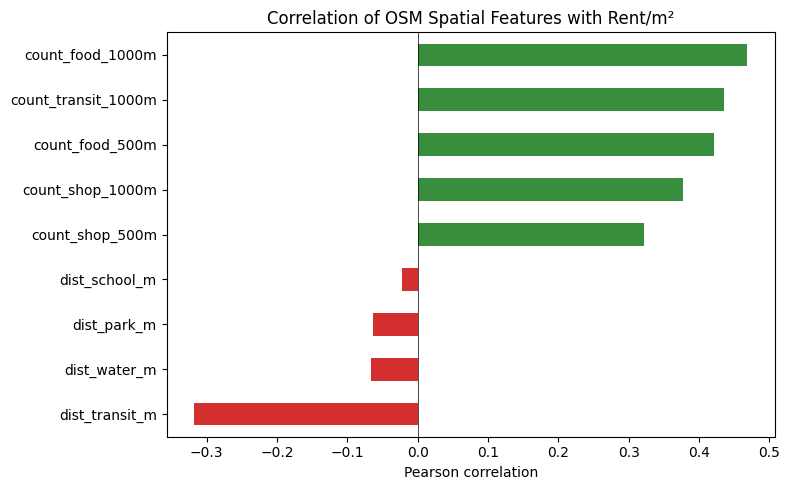


Correlation values:
dist_transit_m        -0.318
dist_water_m          -0.067
dist_park_m           -0.064
dist_school_m         -0.022
count_shop_500m        0.322
count_shop_1000m       0.378
count_food_500m        0.422
count_transit_1000m    0.436
count_food_1000m       0.469


In [10]:
# Merge spatial features to listings by PLZ (both are strings now)
listings_spatial = listings.merge(spatial_df, on="plz", how="left")

# Correlation with rent_sqm
spatial_cols = [c for c in spatial_df.columns if c != "plz"]
corr = listings_spatial[spatial_cols + ["rent_sqm"]].corr()["rent_sqm"].drop("rent_sqm").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind="barh", ax=ax, color=["#d32f2f" if v < 0 else "#388e3c" for v in corr])
ax.set_title("Correlation of OSM Spatial Features with Rent/m²")
ax.set_xlabel("Pearson correlation")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(corr.round(3).to_string())

## 7. Export spatial features

In [11]:
# Save spatial features per PLZ
spatial_df.to_csv("../data/processed/spatial_osm_features.csv", index=False)
print(f"Saved: data/processed/spatial_osm_features.csv ({spatial_df.shape[0]} rows × {spatial_df.shape[1]} cols)")

# Also save the enriched listings (with spatial features joined)
listings_spatial.to_parquet("../data/processed/listings_with_spatial.parquet", index=False)
print(f"Saved: data/processed/listings_with_spatial.parquet ({listings_spatial.shape[0]} rows × {listings_spatial.shape[1]} cols)")

# Save PLZ boundaries for future use
plz_gdf.drop(columns=["centroid"]).to_file("../data/processed/berlin_plz_boundaries.geojson", driver="GeoJSON")
print(f"Saved: data/processed/berlin_plz_boundaries.geojson ({len(plz_gdf)} polygons)")

print("\n--- Features exported ---")
print(spatial_df.columns.tolist())

Saved: data/processed/spatial_osm_features.csv (190 rows × 10 cols)
Saved: data/processed/listings_with_spatial.parquet (10275 rows × 36 cols)
Saved: data/processed/berlin_plz_boundaries.geojson (190 polygons)

--- Features exported ---
['plz', 'dist_transit_m', 'dist_park_m', 'dist_water_m', 'dist_school_m', 'count_food_500m', 'count_shop_500m', 'count_food_1000m', 'count_shop_1000m', 'count_transit_1000m']


## Next steps

- **03b**: Sentinel-2 satellite indices (NDVI, NDWI, NDBI) per PLZ → merge with these OSM features
- **Integration**: Retrain XGBoost with spatial features → measure R² improvement
- **Expected**: transit distance and food/shop density should rank as meaningful SHAP contributors